[활동목표] 머신러닝으로 2030년의 기온을 예측해 보자.

[활동개요]

지구 온난화 등으로 인한 10년 후 기온을 예측하기 위해 문제를 정의하고, 문제 해결에 필요한 데이터를 수집해서 결측치, 이상치 제거 등의 전처리와 시각화를 통해 데이터를 처리한다. 문제 해결에 적합한 머신러닝 알고리즘을 선정하고 정제된 데이터를 학습하여 평가한다. 문제 해결에 적합한 모델이 될 때까지 수정을 한 후
구현된 모델을 배포하는 등의 머신러닝 문제 해결 과정에 따라 2030년의 온도를 예측해 보자.

**기상청 공공 데이터를 이용하여 2030년의 기온을 예측해 보자.**

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt   # 시각화를 위한 라이브러리

# 레티나 디스플레이를 지원하도록 해서 한글이 흐릿하게 보이는 현상 개선
%config InlineBackend.figure_format = 'retina'

#한글 나눔 폰트 사용설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

 # 해당 폰트를 기본 폰트가 되도록 설정
import matplotlib.font_manager as fm
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font = fm.FontProperties(fname=fontpath, size=9)
plt.rc('font', family='NanumBarunGothic')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 16 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

####1. 문제 정의

모든 문제를 머신러닝으로 해결할 수는 없기 때문에 문제가 발생했을 때 머신러닝으로 해결할 수 있는 문제라고 판단이 되면 문제 해결에 필요한 데이터를 수집할 수 있는지를 확인해야 한다. 다음 대화를 읽고 머신러닝으로 해결할 수 있도록 문제를 정의해 보자.
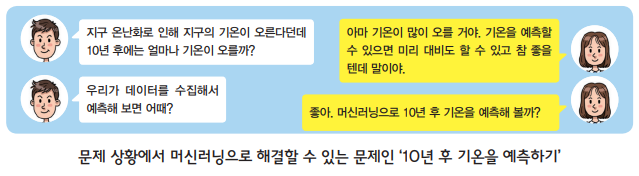

####2. 데이터 수집

직접 수집한 데이터, 공공 데이터, 민간 데이터 등 다양한 방법으로 문제 해결에 적합한 데이터를 수집해 보자. 수집한 데이터에서 이상치나 결측치 등의 데이터를 확인해야 한다.

① 기온 데이터 다운로드

기상 자료 개방 포털 (https://data.kma.go.kr) 의 [기후통계분석]-[통계분석]-[기온분석] 검색창에서 ‘기간’과 ‘지역’을 설정하고 검색하여 기상 테이터 csv 파일을 다운로드한다.

② 데이터 파일 탐색하기

*   pandas 라이브러리로 데이터를 불러오기 전에 다운로드한 csv 파일을 분석해 보자.
*   pandas는 표 형태의 데이터를 읽기 때문에 csv 파일 상단의 기온 분석 관련 정보 행을 삭제한다. 그리고 데이터를 살펴보며 어떤 속성이 있는지 레이블은 어떤 속성으로 정해야 할지 등을 분석한다.

③ 라이브러리 불러오기

필요한 라이브러리를 불러와 다운로드한 파일을 데이터 프레임 형태로 저장해 보자.

In [2]:
#pandas, numpy 및 pyplot 라이브러리를 불러온다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#로컬 컴퓨터의 파일을 코랩에 업로드한다. (1907년~2018년 서울 기온 data)
from google.colab import files
files.upload()

Saving seoul_temp.csv to seoul_temp (2).csv


{'seoul_temp (2).csv': b'\xb3\xe2,\xc1\xf6\xc1\xa1,\xc6\xf2\xb1\xd5\xb1\xe2\xbf\xc2,\xc3\xd6\xc0\xfa\xb1\xe2\xbf\xc2,\xc3\xd6\xb0\xed\xb1\xe2\xbf\xc2\r\n1907,108,,-20.1,25.4\r\n1908,108,10.4,-15.8,33.6\r\n1909,108,10.6,-14.6,35.6\r\n1910,108,10.3,-19.9,33.3\r\n1911,108,10.6,-21.5,34.5\r\n1912,108,10.1,-18.6,34\r\n1913,108,10,-19.6,31.7\r\n1914,108,12,-14,35.6\r\n1915,108,10.8,-21.3,34.8\r\n1916,108,10.9,-19,33.2\r\n1917,108,9.8,-21.1,36.7\r\n1918,108,10.5,-21.8,36.1\r\n1919,108,11.1,-19.3,37.5\r\n1920,108,11.4,-22.3,35.6\r\n1921,108,10.9,-15.3,36\r\n1922,108,10.8,-21,36.3\r\n1923,108,10.6,-20.4,35.9\r\n1924,108,11,-18.7,37.4\r\n1925,108,10.7,-17.4,33.7\r\n1926,108,10.5,-18.6,33\r\n1927,108,11,-23.1,35\r\n1928,108,11.1,-22.2,35.2\r\n1929,108,11.4,-17.5,36.7\r\n1930,108,11.8,-17.4,37.4\r\n1931,108,10.9,-22.5,36\r\n1932,108,11.6,-14.1,37.2\r\n1933,108,10.5,-18.4,35.9\r\n1934,108,10.1,-18.7,33.4\r\n1935,108,11.2,-16.9,33.5\r\n1936,108,9.8,-20.1,34.3\r\n1937,108,11.4,-16,35.1\r\n1938,108,10

In [3]:
#업로드한 ‘seoul_temp.csv’ 파일을 pandas의 데이터 프레임에 저장한다.
#한글 인코딩으로 설정, 헤더를 0번 행으로 지정
df = pd.read_csv('seoul_temp.csv',encoding='cp949',header=0)

#df의 5개 데이터를 출력한다.
df.head()

,년,지점,평균기온,최저기온,최고기온
0,1907,108,NaN,-20.1,25.4
1,1908,108,10.4,-15.8,33.6
2,1909,108,10.6,-14.6,35.6
3,1910,108,10.3,-19.9,33.3
4,1911,108,10.6,-21.5,34.5


####3. 탐색적 데이터 분석 및 데이터 전처리

탐색적 데이터 분석은 데이터의 시각화와 통계치 확인 등을 통해 데이터의 대략적인 정보를 살펴보는 단계이다.

① 데이터 세트의 통계 정보 확인하기

데이터 속성의 통계 대푯값을 확인하고, 데이터 타입, 결측치 등을 확인해 보자.

In [4]:
#데이터 살펴보기 # 데이터의 개수, 평균, 표준편차 등의 대푯값을 분석한다.
df.describe()

,년,지점,평균기온,최저기온,최고기온
count,112.000000,112.0,107.000000,110.000000,110.000000
mean,1962.500000,108.0,11.674766,-16.511818,34.780909
std,32.475632,0.0,0.969740,3.083211,2.517553
min,1907.000000,108.0,9.600000,-23.100000,16.200000
25%,1934.750000,108.0,10.900000,-18.600000,33.925000
50%,1962.500000,108.0,11.600000,-16.850000,35.050000
75%,1990.250000,108.0,12.400000,-14.100000,36.000000
max,2018.000000,108.0,13.800000,-8.600000,39.600000


총 1907년에서 2018년까지 112개 연도의 데이터가 포함되어 있어야 하지만, ‘평균기온’은 107개, ‘최저기온’과 ‘최고기온’은 각각 110개로
데이터 중에 결측치가 있는 것을 확인할 수 있다. 또한 평균값(mean), 표준편차(std), 최솟값(min), 최댓값(max) 및 사분위값(25%, 50%, 75%) 등의 대푯값을 확인할 수 있다.

In [5]:
#데이터 속성별 자료형 확인 # 저장된 데이터의 빈칸이 아닌 값과 자료형을 확인한다.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   년       112 non-null    int64  
 1   지점      112 non-null    int64  
 2   평균기온    107 non-null    float64
 3   최저기온    110 non-null    float64
 4   최고기온    110 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 4.5 KB


전체 데이터는 0~111까지의 인덱스로 이루어져 있으며 112개의 행 데이터가 5개의 속성으로 구성되어 있다. 또한 속성별로 데이터의 개수와 저장된 데이터 형식을 확인할 수 있다.

In [6]:
#속성별로 결측 데이터의 합계를 출력한다.
df.isnull().sum()

년       0
지점      0
평균기온    5
최저기온    2
최고기온    2
dtype: int64

결측치 데이터는 ‘평균기온’ 5개, ‘최저기온’ 2개, ‘최고기온’ 2개가 있다.

In [7]:
# '평균기온'속성에서 결측치 5개만 추출한다.
df[df['평균기온'].isnull()]

,년,지점,평균기온,최저기온,최고기온
0,1907,108,NaN,-20.1,25.4
43,1950,108,NaN,-18.0,36.9
44,1951,108,NaN,NaN,NaN
45,1952,108,NaN,NaN,NaN
46,1953,108,NaN,-9.2,16.2


기온 데이터는 1907년 10월 1일부터 측정을 시작했기 때문에 1907년 ‘평균기온’ 데이터가 없고, ‘최고기온’ 데이터가 이상치일 가능성이 크다. 또한 한국 전쟁으로 인해 1950~1953년까지의 데이터 역시 결측치이고 이상치임을 알 수 있다. 따라서 해당 연도의 데이터는 삭제하는 것이 바람직하다.

② 결측치 데이터 처리하기

*   결측치 데이터는 학습할 데이터가 없어서 그대로 이용할 수 없기 때문에 다음 값으로 채우는 방법(method=‘bfill’), 이전 값으로 채우는 방법(method=‘ffill’), 빈 값을 삭제하는 방법(dropna( )), 특정한 값으로 채우거나(dropna(0)), 평균값 등 대푯값으로 채우는 방법을 사용하여 처리해야 한다.
*   1907년과 한국 전쟁 기간의 데이터는 삭제하는 것이 더 적합해 보이므로 본 활동에서는 빈 값을 삭제하는 방법으로 데이터를 전처리해 보자.

In [8]:
# 결측치를 삭제하고, df에 반영
df.dropna(inplace=True)
df.head()

,년,지점,평균기온,최저기온,최고기온
1,1908,108,10.4,-15.8,33.6
2,1909,108,10.6,-14.6,35.6
3,1910,108,10.3,-19.9,33.3
4,1911,108,10.6,-21.5,34.5
5,1912,108,10.1,-18.6,34.0


③ 탐색적 데이터 분석

데이터를 탐색하기 위해 필요한 속성을 추출하고 변화를 시각화해 보자.

In [9]:
# 데이터 중 속성‘년'의 데이터를 year에 저장한다.
year =  df['년']

# 데이터 중 속성‘평균기온'의 데이터를 temp에 저장한다.
temp = df['평균기온']

# 데이터 중 속성‘최고기온'의 데이터를 mx에 저장한다.
mx = df['최고기온']

#데이터 중 속성 ‘최저기온’의 데이터를 mn에 저장한다
mn = df['최저기온']

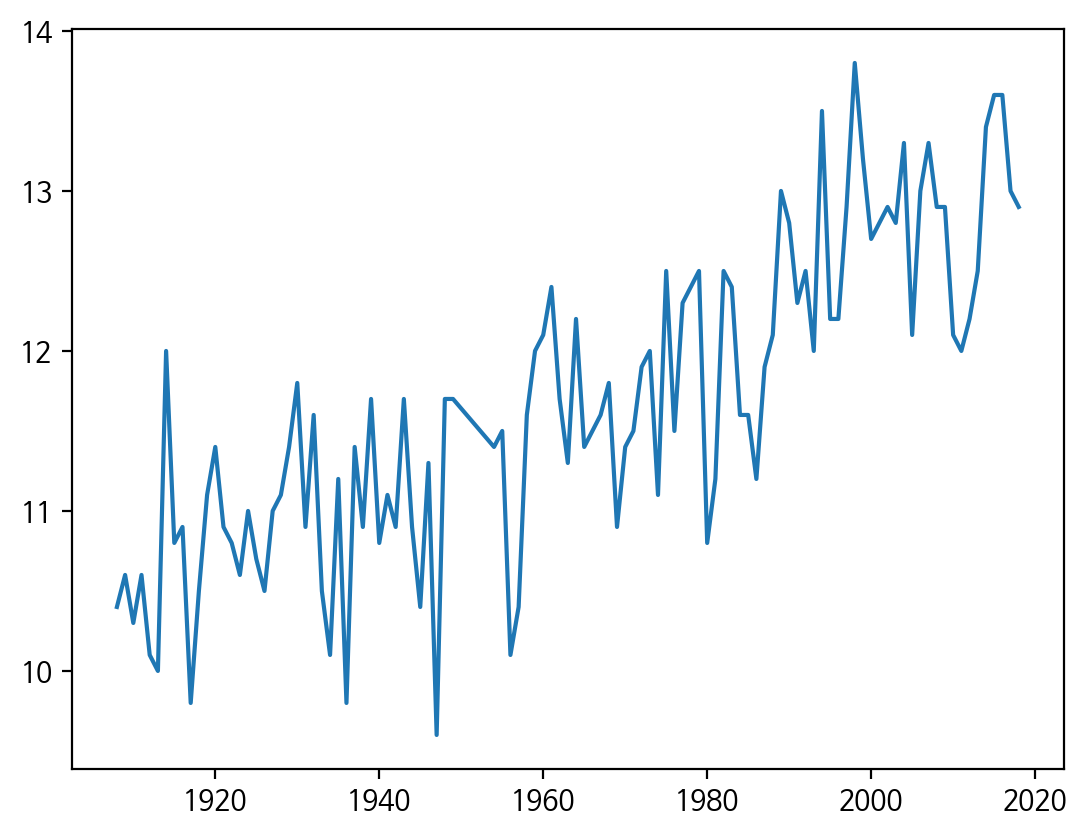

In [10]:
plt.plot(year,temp)
plt.show()

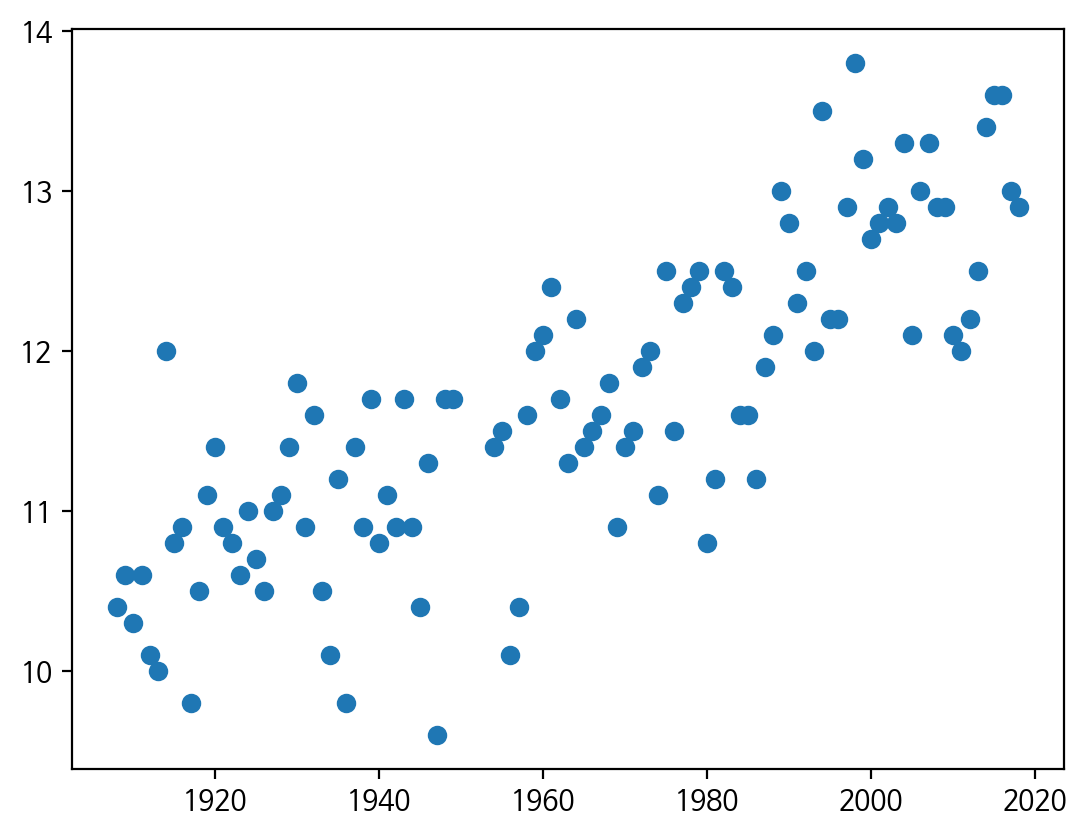

In [11]:
# 산점도(scatter) 그리기
import matplotlib.pyplot as plt
plt.scatter(year,temp)
plt.show()

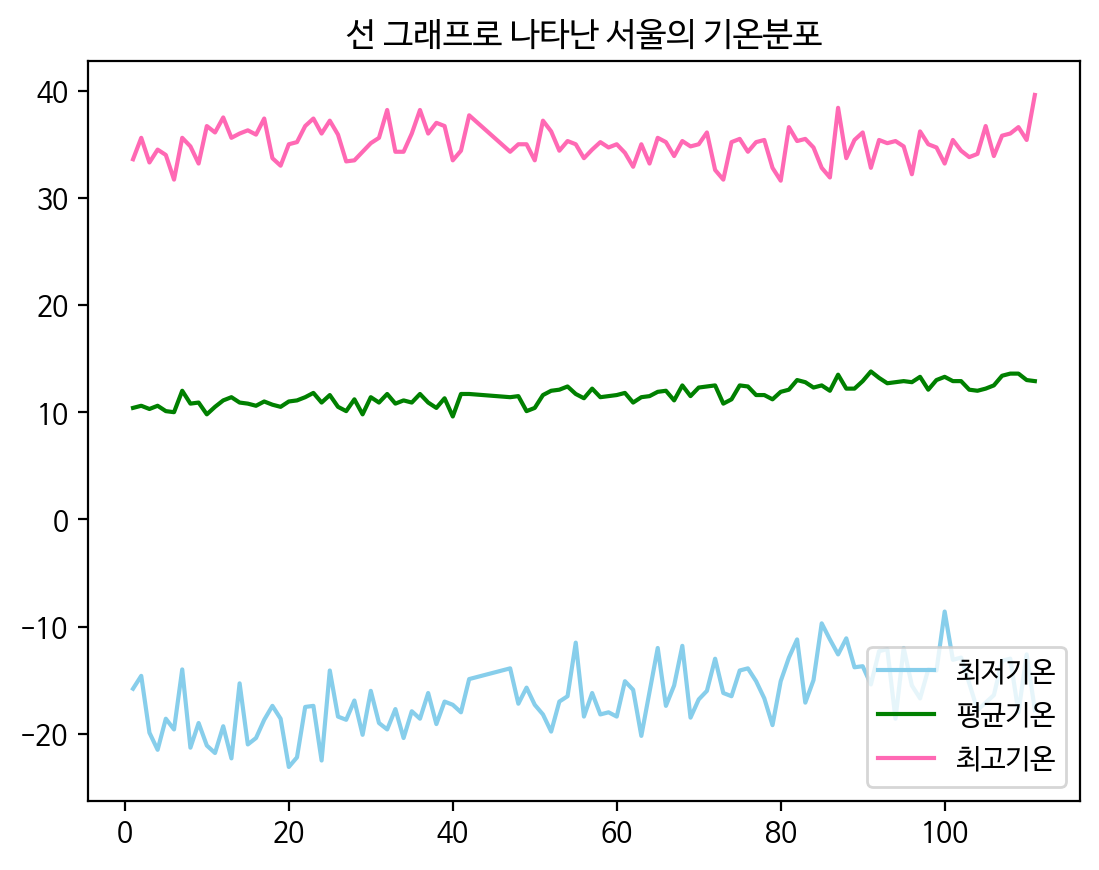

In [12]:
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False
plt.title('선 그래프로 나타난 서울의 기온분포') #선그래프
plt.plot(mn, color='skyblue', label='최저기온')
plt.plot(temp, color='green', label='평균기온')
plt.plot(mx, color='hotpink', label='최고기온')
plt.legend()
plt.show()


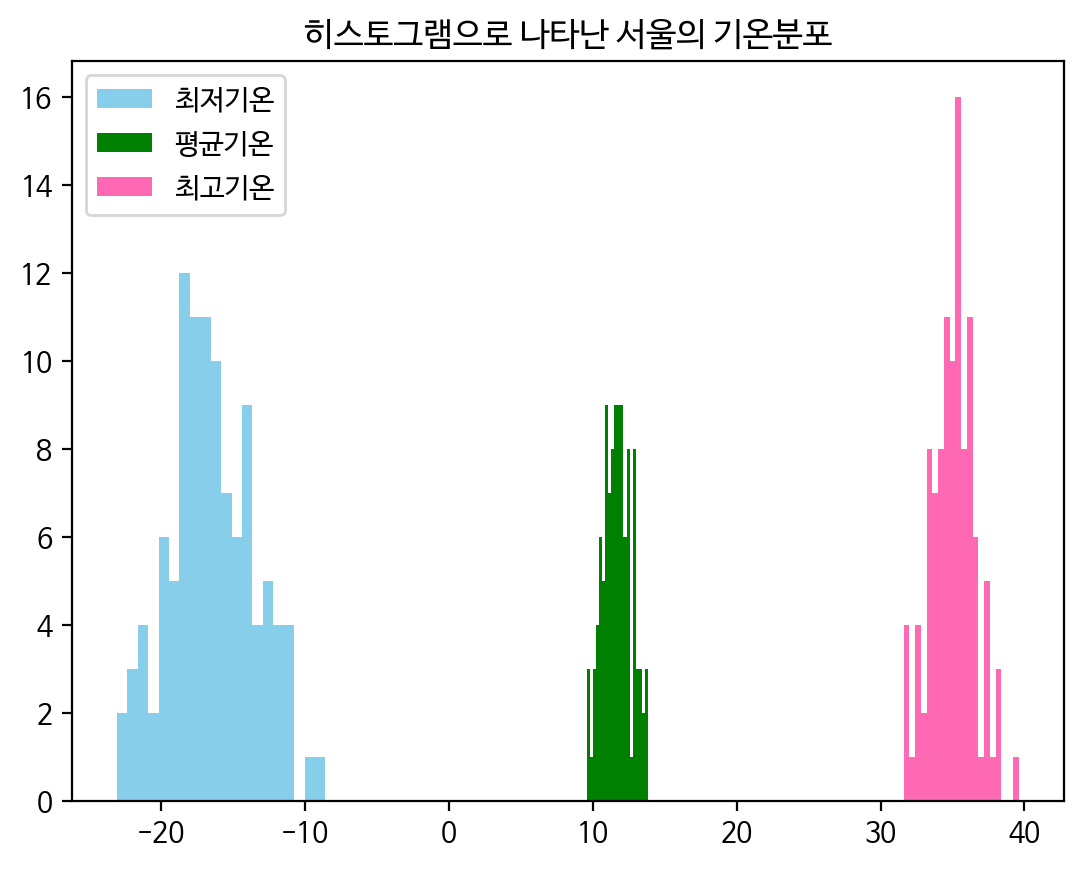

In [13]:
plt.title('히스토그램으로 나타난 서울의 기온분포') #히스토그램
plt.hist(mn, color='skyblue',bins=20, label='최저기온')
plt.hist(temp, color='green',bins=20, label='평균기온')
plt.hist(mx, color='hotpink',bins=20, label='최고기온')
plt.legend()
plt.show()

④ 데이터 전처리

*   ‌머신러닝 라이브러리인 사이킷런(scikit-learn)을 활용하여 훈련용과 평가용 데이터로 나누어 보자.

*   ‌데이터 전처리는 데이터의 결측치와 이상치를 제거하는 것뿐만 아니라 학습에 필요한 속성을 선정하고 훈련용
데이터와 평가용 데이터로 나누는 과정도 포함된다

In [14]:
# numpy : numerical python, 주로 선형대수학 등에 활용
import numpy as np

# 데이터 프레임 중 ‘년’, ‘평균기온’ 데이터를 numpy 배열인 X, y에 저장한다.
x = np.array(df['년'])
y = np.array(df['평균기온'])

# x, y의 크기를 출력한다.
print(x.shape, y.shape)

(107,) (107,)


원 데이터에서 결측치 데이터가 삭제되어 112개 중 107개의 데이터가 numpy 배열 형태로 저장된 것을 확인할 수 있다.

‌train_test_split(데이터, 레이블, test_size=0.25, shuffle=True):
 데이터와 레이블을 설정한 비율과 데이터 섞기에 따라 X_train, X_test, y_train, y_
test의 순서쌍으로 데이터가 반환된다.

*   test_size: 평가용 데이터의 비율로 기본이  0.25이며, 이때 훈련용에는 75%, 평가용에는 25% 데이터와 레이블이 배정된다.
- shuffle: 데이터 세트를 섞을지에 따라 훈련용과 평가용의 데이터가 랜덤하게 바뀐다

In [15]:
# 데이터를 나누기 위해 train_test_split 함수를 불러온다.
from sklearn.model_selection import train_test_split

# 훈련용 데이터(X_train), 평가용 데이터(X_test),
# 훈련용 레이블(y_train), 평가용 레이블(y_test)에 데이터(X)와 레이블(y)을 나눈다.
X_train, X_test, y_train, y_test = train_test_split(x,y,shuffle=False)

# 훈련용 및 평가용 데이터와 레이블의 형태를 출력한다.
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# 훈련용 데이터(X_train)와 평가용 데이터(X_test)를 사이킷런 모델 학습을 위해
# 선형 회귀 모델(사이킷런)이 원하는 형태(2차원 리스트 형태)로 데이터 모양 변환(n행 1열)
X_train = np.reshape(X_train,(-1,1))
X_test = np.reshape(X_test,(-1,1))

# 변환된 훈련용 및 평가용 데이터와 레이블의 형태를 출력한다.
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(80,) (27,) (80,) (27,)
(80, 1) (27, 1) (80,) (27,)


train_test_split( ) 함수를 통해 훈련용 및 평가용 데이터와 레이블이 75:25의 비율로 분할되었다. 사이킷런에서는 학습을 위해 2차원 리스트 형태로 변환해야 하기 때문에 numpy의 reshape 함수를 이용하여 훈련용 데이터와 평가용 데이터의 형태를 바꿔서 출력해 본다.

####4. 모델 학습 및 평가

준비된 데이터를 문제 해결에 적합한 머신러닝 모델로 학습을 하고, 결과를 평가하면서 모델을 구현해 보자. 기온을 예측하기 위해서 회귀 알고리즘을 이용하는 것이 바람직하므로 사이킷런의 선형 회귀 모델을 이용한다.

① 선형 회귀 모델 불러오고 학습하기

훈련용 데이터(X_train)와 훈련용 레이블(y_train)을 fit( ) 함수를 이용하여 선형 회귀 모델을 만들어 보자. 선형회귀 모델은 데이터의 회귀선을 직선으로 나타내는 직선의 기울기와 y절편을 예측하는 모델이 생성된다.

In [16]:
#sklearn의 LinearRegression 함수를 불러온다.
#파이썬에서 머신러닝에 가장 많이 사용되는 라이브러리
from sklearn.linear_model import LinearRegression

#훈련용 데이터와 레이블을 fit( ) 함수로 학습시키고, 그 결과를 model에 저장한다.
model = LinearRegression().fit(X_train, y_train)

In [17]:
# 직선의 기울기(coefficient-계수)와 절편(intercept) 확인
model.coef_, model.intercept_

(array([0.01962474]), -26.970219515752632)

② 데이터 예측하고 평가하기

훈련용 데이터와 레이블에 의해 학습된 모델을 통해 평가용 데이터를 입력했을 때 평균기온을 예측해 보자.

y=ax+b

In [18]:
y_pred = int(input('예측하고 싶은 연도를 입력해주세요 : '))

pred = model.coef_[0] * y_pred + model.intercept_
print(pred)
print(f'{y_pred}년도의 예상 평균 기온은 {pred:.2f}도 입니다.')

예측하고 싶은 연도를 입력해주세요 : 2050
13.260498914170881
2050년도의 예상 평균 기온은 13.26도 입니다.


In [19]:
# 학습된 선형 회귀 모델에 평가용 데이터(X_test)를 입력해서 예측한다. #‌ ‌predict: 학습된 모델을 통해 입력된 데이터를 예측하는 함수
y_pred = model.predict(X_test)

# 평가용 데이터의 형태를 수정해서 출력한다.
print(X_test.reshape(1,-1))
# 예측 결과를 출력한다
print(y_pred)

[[1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005
  2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018]]
[12.12226395 12.14188869 12.16151344 12.18113818 12.20076292 12.22038766
 12.2400124  12.25963714 12.27926188 12.29888662 12.31851136 12.3381361
 12.35776084 12.37738558 12.39701032 12.41663506 12.4362598  12.45588455
 12.47550929 12.49513403 12.51475877 12.53438351 12.55400825 12.57363299
 12.59325773 12.61288247 12.63250721]


평가용 데이터는 1992~2018년으로, 입력한 연도에 따라 평균기온 값을 12.12226395 ~ 12.63250721으로 예측하고 있다.

③ 훈련용 데이터 세트와 평가용 데이터 세트를 그래프로 그리기

학습한 모델을 이용하여 1904~2018년까지 전체 데이터를 표시하고 예측한 결과와 함께 나타내 보자.

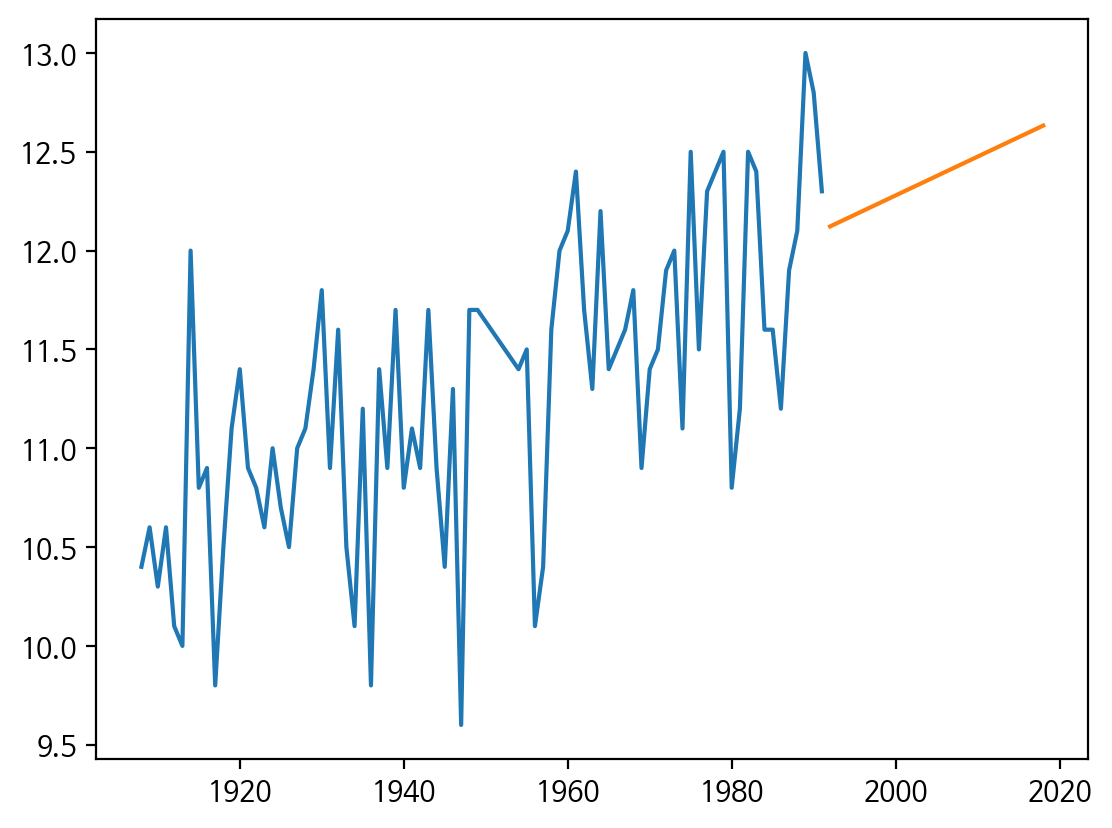

In [20]:
# 훈련용 데이터와 훈련용 레이블을 선그래프로 그린다.
plt.plot(X_train, y_train)

# 평가용 데이터와 예측 레이블을 선그래프로 그린다.
plt.plot(X_test, y_pred)

# 그래프를 표시한다.
plt.show()

훈련용과 평가용으로 분리할 때 shuffle 옵션을 설정하지 않았기
때문에 1907년부터 1991년까지 데이터가 훈련용으로 사용되고,
1992년부터 2018년까지 데이터가 평가용으로 사용되었기 때문에
위와 같은 그래프가 나타났다.

④ 전체 데이터의 예측값 그래프로 그리기

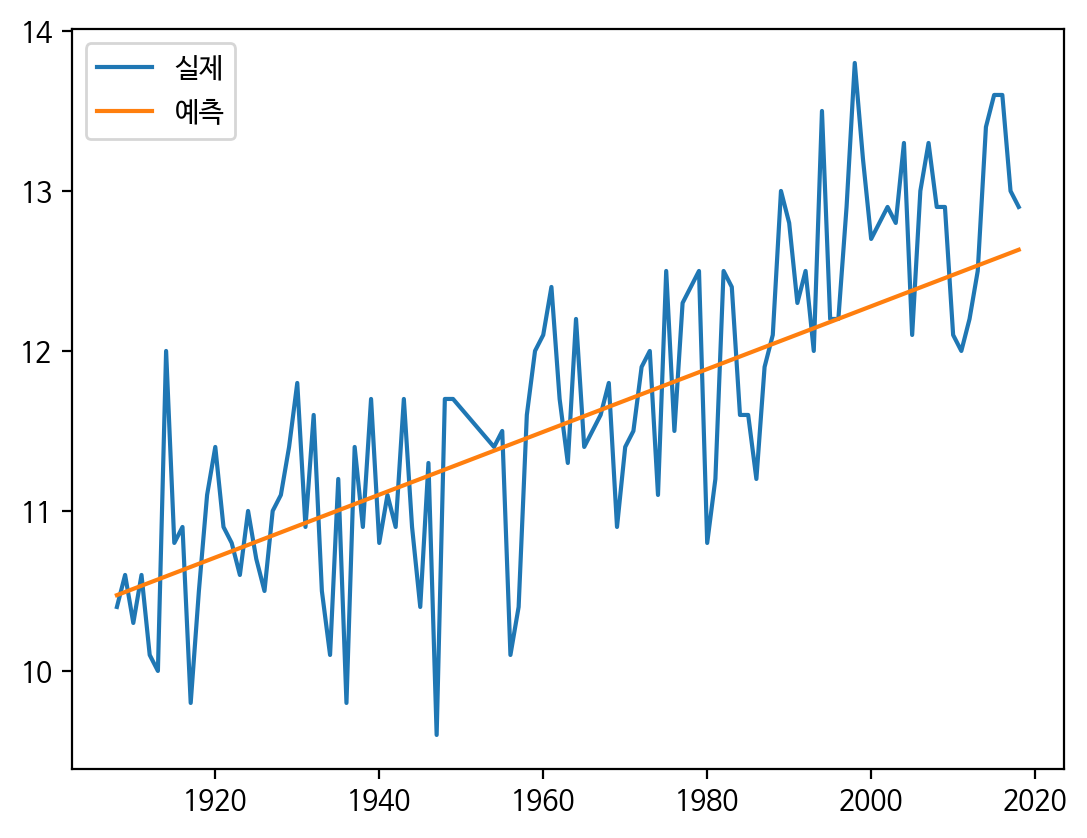

In [21]:
# 전체 데이터를 선그래프로 그린다.
plt.plot(x,y,label='실제')

# 예측한 결과를 선그래프로 그린다. # 예측값 y_all_pred
y_all_pred = model.predict(x.reshape(-1,1))
plt.plot(x, y_all_pred, label="예측")

# 그래프를 표시한다.
plt.legend()
plt.show( )

전체 데이터(X)와 전체 레이블(y)을 선그래프로 나타내고, 전체
데이터(X)를 학습한 선형 회귀 모델에 입력하여 예측한 값(y_all_
pred)을 이용하여 선그래프로 나타낸 것이다.

⑤ 2050년까지 평균 기온 예측하기

1907~2050년까지 x축 numpy 배열을 생성하여 2050년까지 예측된 평균 기온을 그래프로 표시해 보자.

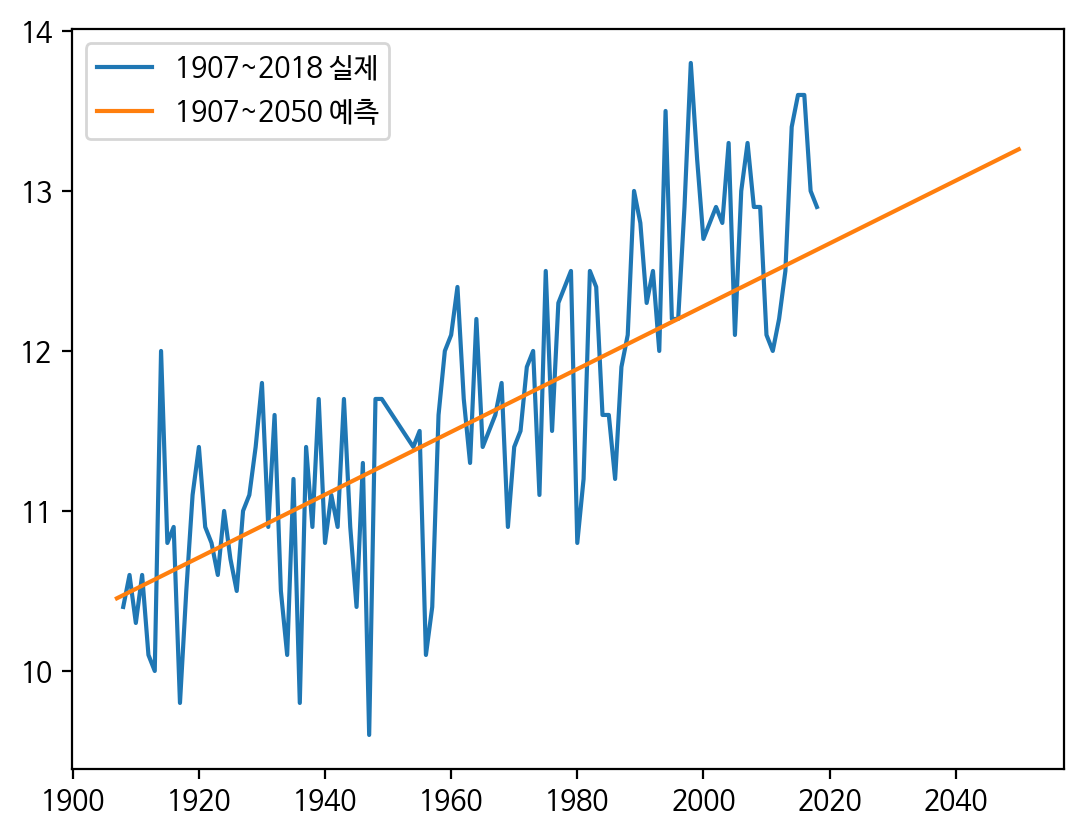

In [22]:
#새로운 데이터의 예측값을 그래프로 그리기

#1907부터 2050까지 numpy 배열을 new_X로 만든다.
new_X = np.arange(1907,2051)

#학습된 선형 회귀 모델에 new_X를 예측한 결과를 new_y에 저장한다.
new_y = model.predict(new_X.reshape(-1,1))

#1907년부터 2018년까지 데이터를 선그래프로 그린다.
#1907년부터 2050년까지 예측한 값을 선그래프로 그린다
plt.plot(x,y,label='1907~2018 실제')
plt.plot(new_X, new_y, label='1907~2050 예측')
plt.legend()
plt.show()

⑥ 2030년 평균 기온 출력하기

2030년부터 2050년까지의 평균 기온 예측값을 출력해 보자.

In [23]:
new_y[-21:]

array([12.8680041 , 12.88762884, 12.90725358, 12.92687832, 12.94650306,
       12.9661278 , 12.98575254, 13.00537729, 13.02500203, 13.04462677,
       13.06425151, 13.08387625, 13.10350099, 13.12312573, 13.14275047,
       13.16237521, 13.18199995, 13.20162469, 13.22124943, 13.24087417,
       13.26049891])

2050년 값 중 2030년은 뒤에서 21번째 값이므로 12.8680041도가 2030년을 예측한 값이다

### 선생님, 그런데 1970년 이전에는...

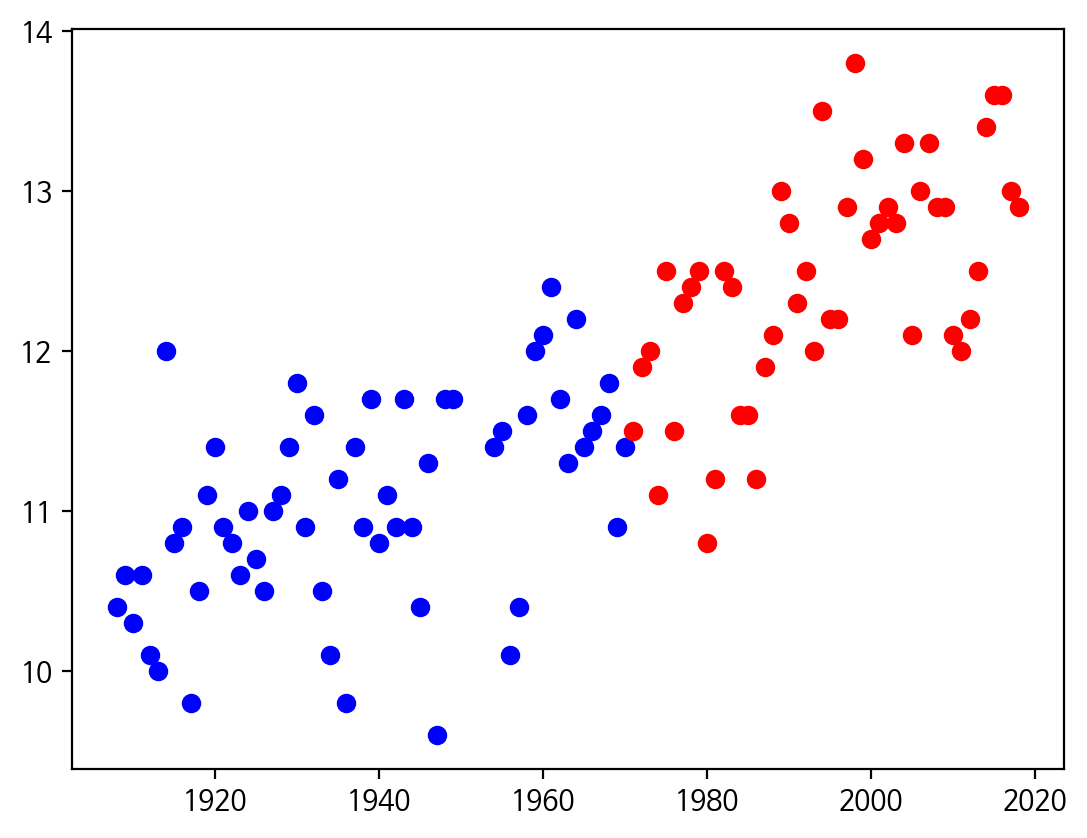

In [24]:
import matplotlib.pyplot as plt
plt.scatter(year[:-48], temp[:-48], color='b')
plt.scatter(year[-48:], temp[-48:], color='r')
plt.show()

In [25]:
x1 = x[:-48]
y1 = y[:-48]

In [26]:
X1_train, X1_test, y1_train, y1_test = train_test_split(x1,y1,shuffle=False)
print(X1_train.shape, X1_test.shape, y1_train.shape, y1_test.shape)

X1_train = np.reshape(X1_train,(-1, 1))
X1_test = np.reshape(X1_test,(-1, 1))
print(X1_train.shape, X1_test.shape, y1_train.shape, y1_test.shape)


(44,) (15,) (44,) (15,)
(44, 1) (15, 1) (44,) (15,)


In [27]:
model1 = LinearRegression( ).fit(X1_train, y1_train)

In [28]:
# 학습된 선형 회귀 모델에 평가용 데이터(X1_test)를 입력해서 예측한다.
#‌ ‌predic1t: 학습된 모델을 통해 입력된 데이터를 예측하는 함수
pred1 = model1.predict(X1_test)

# 예측 결과를 출력한다
print(pred1)

[11.28956833 11.30454329 11.31951826 11.33449322 11.34946818 11.36444314
 11.37941811 11.39439307 11.40936803 11.42434299 11.43931796 11.45429292
 11.46926788 11.48424285 11.49921781]


In [29]:
# 기울기, 절편
model1.coef_, model1.intercept_

(array([0.01497496]), -18.001458386636926)

In [30]:
x2 = x[-48:]
y2 = y[-48:]

X2_train, X2_test, y2_train, y2_test = train_test_split(x2,y2,shuffle=False)

X2_train = np.reshape(X2_train, (-1,1))
X2_test = np.reshape(X2_test, (-1,1))
model2 = LinearRegression().fit(X2_train, y2_train)

#‌ ‌predict: 학습된 모델을 통해 입력된 데이터를 예측하는 함수
pred2 = model2.predict(X2_test)

# 예측 결과를 출력한다
print(pred2)

[13.06888889 13.11015015 13.15141141 13.19267267 13.23393393 13.2751952
 13.31645646 13.35771772 13.39897898 13.44024024 13.4815015  13.52276276]


In [31]:
# model0 : 전체 데이터로 학습한 직선 모델
data1 = np.arange(1907,2051).reshape(-1,1)
pred1 = model.predict(data1)

In [32]:
# model2 : 50년 이전의 데이터로 학습한 직선 모델
data2 = np.arange(1907,1971).reshape(-1,1)
pred2 = model1.predict(data2)

In [33]:
# model3 : 최근 50년 동안의 데이터로 학습한 직선 모델
data3 = np.arange(1971,2051).reshape(-1,1)
pred3 = model2.predict(data3)

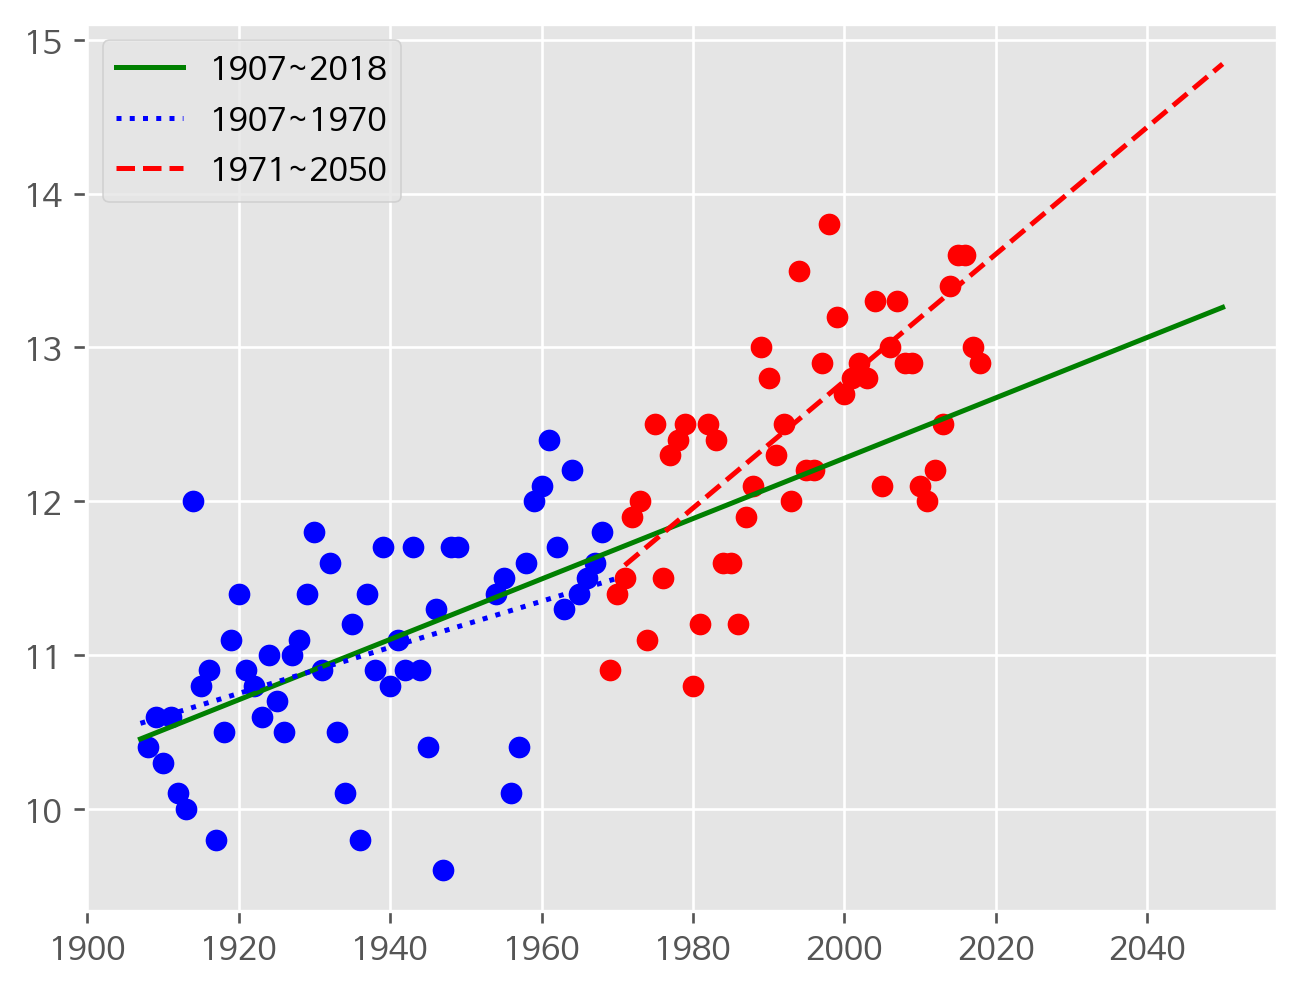

In [34]:
import matplotlib.pyplot as plt
plt.figure(dpi = 120)
plt.style.use('ggplot')
plt.scatter(year[:-50], temp[:-50], color = 'b')
plt.scatter(year[-50:], temp[-50:], color = 'r')
plt.plot(data1 , pred1, 'g', label = '1907~2018')
plt.plot(data2 , pred2, 'b:', label = '1907~1970')
plt.plot(data3 , pred3, 'r--', label = '1971~2050')
plt.legend()
plt.show()